# Interactive fitting of the M87 spectral energy distribution

Use the button at the top to run all the cells in this notebook before you start.

In this tutorial you will fit the observed spectral energy distribution (SED) of M87 by changing physical model parameters. Start with a single emission region, then compare it with BHJet's extended multi-zone jet model. This is meant to be a visual, by-eye fitting exercise: there is no single numerical best answer. Each model updates after you release a control. Record predictions, results, and plot screenshots in the [student workbook](BHJet_student_workbook.docx).

In [2]:
%matplotlib widget

from pathlib import Path
import sys

import astropy.units as u
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from IPython.display import display

OBSERVING_BANDS_HZ = {
    'radio': 2.4e9, 'sub-mm': 2.4e11, 'infrared': 2.4e13,
    'optical/UV': 4.8e15, 'X-ray': 2.4e18, 'gamma-ray': 2.4e22,
}

def add_observing_band_labels(ax):
    for label, frequency_hz in OBSERVING_BANDS_HZ.items():
        ax.text(frequency_hz, 1.02, label, transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=9, clip_on=False)

def find_repository_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if ((candidate / 'tutorials' / 'tutorial_data').is_dir()
                and (candidate / 'examples' / 'interactive' / 'bhjet_tutorial_explorer.py').is_file()):
            return candidate

def print_parameters(explorer):
    """Print the current model parameters to a dict"""
    print('saved_parameters = {')
    for name, value in explorer.get_parameters().items():
        print(f'    {name!r}: {value!r},')
    print('}')

def load_parameters(explorer, saved_parameters):
    """Load a parameter dict for the plot widgets"""
    explorer.set_parameters(saved_parameters)

repository_root = find_repository_root()

sys.path.insert(0, str(repository_root / 'examples' / 'interactive'))

from bhjet_tutorial_explorer import OneZoneFittingExplorer

def load_m87_radio_xray_data(path):
    raw = Table.read(path, format='ascii.no_header')
    data = Table()
    frequency_min = np.asarray(raw['col1'], dtype=float) * u.Hz
    frequency_max = np.asarray(raw['col2'], dtype=float) * u.Hz
    data['frequency_hz'] = np.sqrt(frequency_min * frequency_max)
    data['nu_fnu'] = np.asarray(raw['col3'], dtype=float) * u.erg / (u.cm**2 * u.s)
    data['nu_fnu_error'] = np.asarray(raw['col4'], dtype=float) * u.erg / (u.cm**2 * u.s)
    return data

data_file = repository_root / 'tutorials' / 'tutorial_data' / 'm87_radio_xray.txt'
data = load_m87_radio_xray_data(data_file)

data_frequency = data['frequency_hz'].quantity
data_energy = data_frequency.to(u.eV, equivalencies=u.spectral())
data_sed = data['nu_fnu'].quantity
data_sed_error = data['nu_fnu_error'].quantity

data_flux_density = (data_sed / data_frequency).to(u.mJy)


M87_MULTI_ZONE_DEFAULTS = {
    'lg_10_jet_power_eddington': np.log10(2e-4),
    'lg_10_z_jet_launching': np.log10(2.0),
    'lg_10_r_initial': np.log10(9.0),
    'lg_10_z_end_of_acceleration': np.log10(100.0),
    'lg_10_z_dissipation': np.log10(100.0),
    'lg_10_z_max_calculation': np.log10(1e6),
    'lg_10_sigma_final': np.log10(0.1),
    'gamma_final': 2.1,
    'plasma_beta_jet_base': 0.02,
    'lg_10_electron_temperature_jet_base': np.log10(500.0),
    'gamma_acceleration_exponent': 0.2,
    'lg_10_opening_angle_constant': np.log10(0.15),
    'lg_10_fraction_nonthermal_electrons': np.log10(0.5),
    'lg_10_factor_break_electrons': np.log10(0.1),
    'lg_10_factor_max_energy_electrons': np.log10(8e-9),
    'index_injected_electrons': 1.75,
    'dlgz': 0.1,
}

## 0. Source Properties

In [3]:
# need to first set the specifics of the source we want to focus on: 
SOURCE_NAME = 'M87'
DISTANCE_KPC = 29_400
REDSHIFT = 0.007465
VIEWING_ANGLE_DEG = 17.0
BLACK_HOLE_MASS_SOLAR = 1.6e9

## 1. Creating a single emission zone: 

In [11]:
one_zone_explorer = OneZoneFittingExplorer(
    distance=DISTANCE_KPC, redshift=REDSHIFT, theta_obs=VIEWING_ANGLE_DEG,
    observation_energy_eV=data_energy.to_value(u.eV),
)
one_zone_explorer.display()

#### Example: If you converge on a solution, and you want to save the entire parameter list that you have: 

Use this function, as it will print out your entire list of parameters, then copy it into the notebook. You can use it to load this set of parameters for the widget. Make sure you change the name depending on what parameters you're saving (the multi-zone parameters are called multi_zone_explorer)

In [12]:
# Run this after changing a model, then copy the output into your notes.
print_parameters(one_zone_explorer)


saved_parameters = {
    'geometry': 'sphere',
    'magnetic_field': 0.2,
    'radius': 1e+16,
    'height': 1e+16,
    'bulk_momentum': 2.0,
    'electron_number_density': 1000.0,
    'electron_temperature': 900.0,
    'fraction_nonthermal_electrons': 0.1,
    'factor_break_electrons': 0.1,
    'factor_max_energy_electrons': 1e-07,
    'index_injected_electrons': 1.8,
}


In [13]:
# To load a copied list later, paste it into a new cell and run:
saved_parameters = {
    'geometry': 'sphere',
    'magnetic_field': 0.2,
    'radius': 1e+16,
    'height': 1e+16,
    'bulk_momentum': 2.0,
    'electron_number_density': 1000.0,
    'electron_temperature': 900.0,
    'fraction_nonthermal_electrons': 0.1,
    'factor_break_electrons': 0.1,
    'factor_max_energy_electrons': 1e-07,
    'index_injected_electrons': 1.8,
}
load_parameters(one_zone_explorer, saved_parameters)

## 2. Compare the single “blob” with observations of M87


### A. Plot the observations
The black points are the measurements across the MWL specrum that we will try to reproduce. Their horizontal axis is photon energy and the vertical axis is $\nu F_\nu$: the energy received per unit area and time in each logarithmic energy interval. 

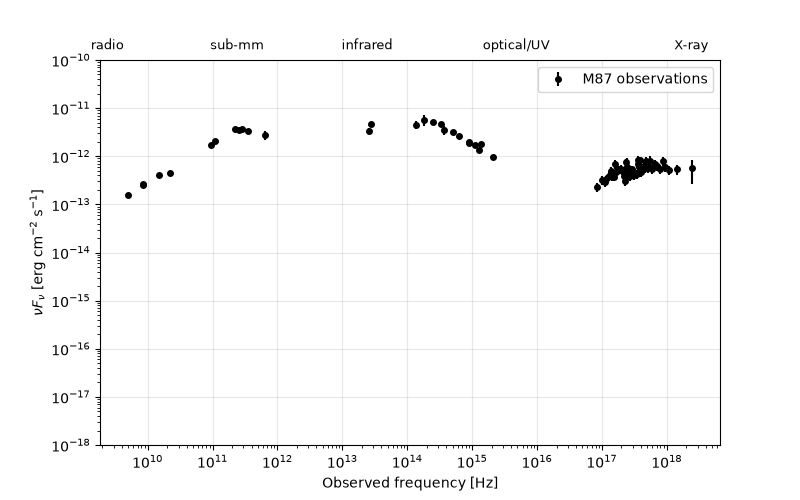

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(data_frequency.to_value(u.Hz), data_sed.value, yerr=data_sed_error.value,
            fmt='o', ms=4, color='black', label='M87 observations')
ax.set(xscale='log', yscale='log', xlabel='Observed frequency [Hz]',
       ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]')
ax.set_ylim(1e-18, 1e-10)
ax.grid(alpha=0.3)
add_observing_band_labels(ax)
ax.legend();

### B. Fit M87 with one emission zone

The magnetic field, sizes, density, temperature, non-thermal fraction, and electron-energy factors are all in log-space; their labels show the physical units. 

In [6]:
one_zone_explorer = OneZoneFittingExplorer(
    distance=DISTANCE_KPC, redshift=REDSHIFT, theta_obs=VIEWING_ANGLE_DEG,
    observation_energy_eV=data_energy.to_value(u.eV),
    observation_sed=data_sed.value,
    observation_sed_error=data_sed_error.value,
    observation_label='M87 observations',
)
one_zone_explorer.display()

## 3. Fit M87 with a multi-zone BHJet model

BHJet reproduces changing conditions along the jet by calculating many stacked "blobs" or regions with distance from the black hole, and calculates what the radiation would be from these zones. This panel includes the same teaching parameters as notebook 1, including black-body controls and the option to link particle dissipation to the end of bulk accelearation.

In [7]:
from bhjet_tutorial_explorer import BHJetExplorer

multi_zone_defaults = M87_MULTI_ZONE_DEFAULTS.copy()
multi_zone_defaults.update({
    'theta_obs': VIEWING_ANGLE_DEG,
    'lg_10_distance': np.log10(DISTANCE_KPC),
    'redshift': REDSHIFT,
    'lg_10_mass_bh': np.log10(BLACK_HOLE_MASS_SOLAR),
})

multi_zone_explorer = BHJetExplorer(
    verbosity_level=0, Emin_eV=1e-9, Emax_eV=1e13, n_energy=220,
    defaults=multi_zone_defaults,
    observation_energy_eV=data_energy.to_value(u.eV),
    observation_sed=data_sed.value,
    observation_sed_error=data_sed_error.value,
    observation_label=f'{SOURCE_NAME} observations',
)
multi_zone_explorer.display()

## 4. Compare your current models

The following plot uses the current model in each panel. If you change either panel, wait for its plot to update before refreshing this comparison.

In [8]:
plt.ioff()
comparison_figure, comparison_axis = plt.subplots(figsize=(9, 5))
compare_button = widgets.Button(description='Compare current models', button_style='primary')
comparison_status = widgets.Label()

def plot_current_models(_=None):
    one_zone_energy_eV, one_zone_sed = one_zone_explorer.get_total_sed()
    one_zone_components = one_zone_explorer.get_component_seds()
    multi_zone_energy_eV, multi_zone_sed = multi_zone_explorer.get_total_sed()
    comparison_axis.clear()
    comparison_axis.errorbar(data_frequency.to_value(u.Hz), data_sed.value, yerr=data_sed_error.value,
                             fmt='o', ms=4, color='black', label='M87 observations')
    one_zone_frequency_hz = (one_zone_energy_eV * u.eV).to_value(u.Hz, equivalencies=u.spectral())
    multi_zone_frequency_hz = (multi_zone_energy_eV * u.eV).to_value(u.Hz, equivalencies=u.spectral())
    comparison_axis.loglog(one_zone_frequency_hz, one_zone_sed,
                           c='k', lw=2, alpha=0.8, label='one-zone total')
    synchrotron_energy_eV, synchrotron_sed = one_zone_components['synchrotron']
    synchrotron_frequency_hz = (synchrotron_energy_eV * u.eV).to_value(u.Hz, equivalencies=u.spectral())
    comparison_axis.loglog(synchrotron_frequency_hz, synchrotron_sed, c='tab:blue', ls='--',
                           lw=1.5, label='one-zone synchrotron')
    ssc_energy_eV, ssc_sed = one_zone_components['ssc']
    ssc_frequency_hz = (ssc_energy_eV * u.eV).to_value(u.Hz, equivalencies=u.spectral())
    comparison_axis.loglog(ssc_frequency_hz, ssc_sed, c='tab:red', ls='--',
                           lw=1.5, label='one-zone SSC')
    comparison_axis.loglog(multi_zone_frequency_hz, multi_zone_sed,
                           lw=2, label='multi-zone BHJet model')
    comparison_axis.set(xscale='log', yscale='log', xlim=(1e5, 3e27),
                        ylim=(1e-18, 1e-10), xlabel='Observed frequency [Hz]',
                        ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]')
    comparison_axis.grid(alpha=0.3)
    add_observing_band_labels(comparison_axis)
    comparison_axis.legend()
    comparison_figure.canvas.draw_idle()
    comparison_status.value = 'Comparison updated.'

compare_button.on_click(plot_current_models)
plot_current_models()
display(widgets.VBox([comparison_figure.canvas, widgets.HBox([compare_button, comparison_status])]))